# Multi-Agent Marketing Operations System

A multi-agent system built with the **Gemini API** (reasoning/generation) and the **Tavily API** (live web search), designed to actually *run* marketing operations, not just draft a single post.

## The four agents

| # | Agent | Responsibility |
|---|-------|-----------------|
| 1 | `MarketingAgent` | Cross-platform marketing strategy + platform-native post drafting. |
| 2 | `LeadGenAgent` | Live web search (Tavily) → qualified lead list against an ICP. |
| 3 | `CampaignOpsAgent` | **Campaign & ads operations**: multi-platform ad copy variants, budget-split recommendation, an auto-generated content calendar, batch poster rendering, and automated comment/DM triage — packaged into one downloadable handoff file. |
| 4 | `RevenuePredictorAgent` | Revenue/cost/profit forecasting + executive narrative. |

A fifth component, `OrchestratorAgent`, coordinates all four: give it one plain-English business goal and it decides which agents to call and in what order.

## What's new in this version

The previous version's Agent 3 only produced *one* poster and replied to a handful of hand-typed comments — useful for a demo, not for running actual operations. This version turns it into a real **campaign operations agent**:

- Generates **multiple ad copy variants per platform** (Meta Ads, Google Ads, LinkedIn Ads, etc.), exported as a CSV shaped for handoff to whoever manages those ad accounts.
- Recommends a **budget split** across platforms with a chart and reasoning.
- Auto-builds a **content calendar** (day-by-day: platform, topic, caption, recommended posting time).
- **Batch-renders posters** for the calendar's key moments and produces a contact sheet for quick visual review.
- **Triages incoming comments/DMs at scale** — classifies sentiment/urgency, drafts a reply, and flags anything that needs a human before it goes out.
- **Packages everything into one .zip** (`campaign_package_<timestamp>.zip`) ready to hand to whoever runs the ad accounts / social scheduler.
- A **fill-in-the-form UI** (built with `ipywidgets`) replaces hand-editing a Python dictionary — click one button and the whole operation runs.

## Honest limitation

This system **prepares** campaigns — ad copy, budget plan, calendar, creative, reply drafts — ready for a human (or a connected ad-platform integration) to publish. It does **not** push ads live to Meta/Google Ads accounts: that requires each platform's own OAuth app review and a connected business ad account, which is a separate integration step, not something a free API key alone provides. Worth saying this plainly if asked "does it publish automatically?" — the honest answer is "it prepares everything for publishing, one click of handoff away."

## Tech stack (100% free-tier)

- **LLM reasoning / content generation:** Google Gemini API (`google-genai`, `gemini-2.5-flash`)
- **Live web search for leads:** Tavily API (`tavily-python`)
- **Data / forecasting:** pandas, scikit-learn, matplotlib
- **Poster rendering:** Pillow (PIL)
- **Interactive form:** `ipywidgets` (pre-installed in Colab)

> Run every cell top to bottom once (**Runtime → Run all**). The interactive form near the bottom only works after that — standard Colab behaviour, not a bug.


## Step 1 — Install dependencies

In [1]:
!pip install -q -U google-genai tavily-python pandas==2.2.3 google-auth==2.49.0 matplotlib pillow scikit-learn ipywidgets

In [2]:
!pip install pillow

## Step 2 — Configure API clients

Reads `GEMINI_API_KEY` and `TAVILY_API_KEY` from **Colab Secrets** (key icon, left sidebar) and falls back to environment variables outside Colab.


In [3]:
import os, json, re, time, zipfile
from datetime import datetime, timedelta

from google import genai
from google.genai import types as genai_types
from tavily import TavilyClient

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from sklearn.linear_model import LinearRegression

import ipywidgets as widgets
from IPython.display import display, clear_output

try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')
except Exception:
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
    TAVILY_API_KEY = os.environ.get('TAVILY_API_KEY')

assert GEMINI_API_KEY, "GEMINI_API_KEY not found. Add it via the key icon in the left sidebar (Secrets)."
assert TAVILY_API_KEY, "TAVILY_API_KEY not found. Add it via the key icon in the left sidebar (Secrets)."

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

# Free-tier friendly model. If you hit a 429 (rate limit) error, switch this
# to "gemini-2.0-flash" or "gemini-flash-lite-latest".
GEMINI_MODEL = "gemini-flash-lite-latest"

print("Gemini client ready. Tavily client ready.")


Gemini client ready. Tavily client ready.


## Step 3 — Shared agent infrastructure

Every agent inherits from `BaseAgent` and reads/writes one shared `AgentMemory` (a blackboard). `call_gemini()` is the single, central wrapper — retries, JSON parsing and error handling live in one place and every agent reuses it.


In [4]:
class AgentMemory:
    """Shared blackboard: lets agents read outputs produced by other agents."""

    def __init__(self):
        self._store = {}

    def write(self, key, value):
        self._store[key] = value

    def read(self, key, default=None):
        return self._store.get(key, default)

    def keys(self):
        return list(self._store.keys())


def call_gemini(prompt, system_instruction=None, json_mode=False, retries=3):
    """Central wrapper around the Gemini API with retry/backoff and optional
    JSON-only output."""
    config = genai_types.GenerateContentConfig(
        system_instruction=system_instruction,
        response_mime_type="application/json" if json_mode else "text/plain",
        temperature=0.6,
    )
    last_err = None
    for attempt in range(retries):
        try:
            response = gemini_client.models.generate_content(
                model=GEMINI_MODEL, contents=prompt, config=config,
            )
            text = response.text
            if json_mode:
                cleaned = re.sub(r"^```json|```$", "", text.strip(), flags=re.MULTILINE).strip()
                return json.loads(cleaned)
            return text
        except Exception as e:
            last_err = e
            wait = 2 ** attempt
            print(f"[call_gemini] attempt {attempt + 1}/{retries} failed: {e}. Retrying in {wait}s...")
            time.sleep(wait)
    raise RuntimeError(f"Gemini call failed after {retries} attempts: {last_err}")


class BaseAgent:
    """Common interface so the orchestrator can treat every agent the same way."""
    name = "base_agent"
    description = "Base agent class."

    def __init__(self, memory: AgentMemory):
        self.memory = memory

    def run(self, **kwargs):
        raise NotImplementedError


## Agent 1 — `MarketingAgent`

Builds a cross-platform marketing strategy and drafts platform-native posts.


In [5]:
class MarketingAgent(BaseAgent):
    name = "marketing_agent"
    description = (
        "Builds cross-platform marketing strategy and drafts platform-native "
        "social/ad copy for a given product, audience and goal."
    )

    def build_strategy(self, product, audience, platforms, goal):
        prompt = f"""
You are a senior marketing strategist. Create a marketing plan.

Product / brand: {product}
Target audience: {audience}
Platforms: {', '.join(platforms)}
Primary goal: {goal}

Return ONLY a JSON object with this exact shape:
{{
  "positioning": "one paragraph positioning statement",
  "key_messages": ["message 1", "message 2", "message 3"],
  "platform_plan": {{
      "<platform name>": {{
          "content_pillars": ["pillar 1", "pillar 2"],
          "posting_cadence": "e.g. 4x/week",
          "tone": "short description of tone/voice for this platform"
      }}
  }},
  "kpis": ["kpi 1", "kpi 2", "kpi 3"]
}}
"""
        strategy = call_gemini(prompt, json_mode=True)
        self.memory.write("marketing_strategy", strategy)
        return strategy

    def generate_post(self, platform, topic, tone="on-brand and energetic"):
        prompt = f"""
Write one ready-to-publish social media post for {platform} about: {topic}.
Tone: {tone}. Follow {platform}'s conventions (length, hashtags, emojis where appropriate).
Return plain text only, no explanations.
"""
        post = call_gemini(prompt)
        self.memory.write(f"post::{platform}::{topic}", post)
        return post

    def run(self, product, audience, platforms, goal):
        return self.build_strategy(product, audience, platforms, goal)


## Agent 2 — `LeadGenAgent`

Uses **Tavily** to search the live web for organisations matching an Ideal Customer Profile (ICP), then Gemini structures the raw results into a qualified lead list.


In [6]:
class LeadGenAgent(BaseAgent):
    name = "lead_gen_agent"
    description = (
        "Searches the live web (Tavily) for prospects matching an ICP, then "
        "uses Gemini to qualify and structure them into a lead list."
    )

    def find_leads(self, icp_description, industry, region, max_results=8):
        query = f"{icp_description} in {industry} industry, based in {region}"

        search_results = tavily_client.search(
            query=query, search_depth="advanced", max_results=max_results, include_answer=False,
        )
        raw_hits = [
            {"title": r.get("title", ""), "url": r.get("url", ""), "content": r.get("content", "")[:1000]}
            for r in search_results.get("results", [])
        ]

        prompt = f"""
You are a B2B lead-qualification analyst. Below are raw web search results
for the query: "{query}"

Search results (JSON):
{json.dumps(raw_hits, indent=2)}

Ideal Customer Profile: {icp_description}

For each result that plausibly matches the ICP, extract a qualified lead.
Discard irrelevant results. Return ONLY a JSON array, each item shaped like:
{{
  "organization": "name",
  "why_it_fits": "one sentence",
  "likely_contact_channel": "e.g. LinkedIn / company contact page / email",
  "confidence": "high | medium | low",
  "source_url": "url"
}}
"""
        leads = call_gemini(prompt, json_mode=True)
        df = pd.DataFrame(leads)
        self.memory.write("leads_df", df)
        self.memory.write("leads_query", query)
        return df

    def run(self, icp_description, industry, region, max_results=8):
        return self.find_leads(icp_description, industry, region, max_results)


## Agent 3 — `CampaignOpsAgent` (campaign marketing & ads automation)

This is the agent your operations actually run on. It covers five jobs a human campaign manager normally does by hand:

1. `generate_ad_variants` — multiple ad copy variants per platform, exportable as CSV
2. `recommend_budget_split` — how to split ad spend across platforms, with a chart
3. `generate_content_calendar` — a day-by-day organic content plan
4. `batch_render_posters` — creative for the calendar's key moments + a contact sheet
5. `automate_engagement` — triages a batch of comments/DMs: sentiment, urgency, draft reply, human-review flag

`export_package()` zips all of the above into one file so it's a clean handoff, not six separate outputs to chase down.


In [7]:
class CampaignOpsAgent(BaseAgent):
    name = "campaign_ops_agent"
    description = (
        "Automates campaign/ads operations: multi-platform ad copy variants, "
        "budget-split recommendation, content calendar, batch poster creative, "
        "and automated comment/DM triage — packaged for handoff."
    )

    PALETTES = {
        "energetic": [(255, 87, 34), (255, 193, 7)],
        "premium":   [(20, 20, 30), (120, 100, 60)],
        "calm":      [(30, 90, 110), (170, 210, 200)],
    }

    def __init__(self, memory, workdir="campaign_assets"):
        super().__init__(memory)
        self.workdir = workdir
        os.makedirs(self.workdir, exist_ok=True)

    # ---------- 1. Ad copy variants -----------------------------------
    def generate_ad_variants(self, brief, platforms, audience, num_variants=3):
        prompt = f"""
You are a senior performance-ads copywriter. Campaign brief: {brief}
Target audience: {audience}
Platforms: {', '.join(platforms)}

For EACH platform, write {num_variants} distinct ad copy variants, respecting
that platform's typical constraints (e.g. Meta Ads: short punchy headline,
~125 char primary text; Google Ads: multiple short headlines under ~30 chars,
descriptions under ~90 chars; LinkedIn Ads: slightly more professional tone).

Return ONLY a JSON array, one item per variant:
[
  {{
    "platform": "platform name",
    "variant": 1,
    "headline": "...",
    "primary_text": "...",
    "description": "...",
    "cta": "e.g. Shop Now / Learn More / Sign Up"
  }}
]
"""
        variants = call_gemini(prompt, json_mode=True)
        df = pd.DataFrame(variants)
        self.memory.write("ad_variants_df", df)
        return df

    # ---------- 2. Budget split -----------------------------------------
    def recommend_budget_split(self, total_budget, platforms, goal):
        prompt = f"""
You are a paid-media planner. Total ad budget: {total_budget}
Platforms available: {', '.join(platforms)}
Campaign goal: {goal}

Recommend a percentage budget split across platforms that should sum to 100.
Return ONLY a JSON array:
[{{"platform": "name", "percent": 40, "rationale": "one sentence"}}]
"""
        split = call_gemini(prompt, json_mode=True)
        df = pd.DataFrame(split)
        # Defensive normalisation in case the model's percentages don't sum to exactly 100
        df["percent"] = df["percent"].astype(float)
        df["percent"] = df["percent"] / df["percent"].sum() * 100
        df["budget_amount"] = (df["percent"] / 100 * float(total_budget)).round(0)
        self.memory.write("budget_split_df", df)
        return df

    def plot_budget_split(self, budget_df):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.pie(budget_df["percent"], labels=budget_df["platform"], autopct="%1.0f%%")
        ax.set_title("Recommended ad budget split")
        plt.tight_layout()
        plt.show()

    # ---------- 3. Content calendar --------------------------------------
    def generate_content_calendar(self, brief, platforms, start_date, num_days=7):
        dates = pd.date_range(start=start_date, periods=num_days, freq="D")
        skeleton = [
            {"date": str(d.date()), "platform": platforms[i % len(platforms)]}
            for i, d in enumerate(dates)
        ]

        prompt = f"""
You are a social media content planner. Campaign brief: {brief}

Here is a fixed schedule skeleton (JSON, {len(skeleton)} entries, in order):
{json.dumps(skeleton, indent=2)}

For EACH entry in the same order, come up with a topic, a ready-to-publish
caption for that platform, and a recommended posting time. Return ONLY a
JSON array of exactly {len(skeleton)} objects, in the same order:
[{{"topic": "...", "caption": "...", "recommended_time": "e.g. 10:00 AM"}}]
"""
        fills = call_gemini(prompt, json_mode=True)
        assert len(fills) == len(skeleton), "Model returned a different number of calendar entries than requested."

        for row, fill in zip(skeleton, fills):
            row.update(fill)

        calendar_df = pd.DataFrame(skeleton)
        self.memory.write("content_calendar_df", calendar_df)
        return calendar_df

    # ---------- 4. Poster rendering ---------------------------------------
    def generate_poster_copy(self, brief):
        prompt = f"""
Write poster copy for this campaign brief: {brief}
Return ONLY JSON:
{{"headline": "max 6 words", "subheadline": "max 12 words", "cta": "max 4 words",
  "mood": "one of: energetic, premium, calm"}}
"""
        return call_gemini(prompt, json_mode=True)

    def render_poster(self, copy_dict, filename, size=(1080, 1350)):
        mood = copy_dict.get("mood", "energetic")
        top_color, bottom_color = self.PALETTES.get(mood, self.PALETTES["energetic"])

        img = Image.new("RGB", size, top_color)
        draw = ImageDraw.Draw(img)
        for y in range(size[1]):
            ratio = y / size[1]
            r = int(top_color[0] * (1 - ratio) + bottom_color[0] * ratio)
            g = int(top_color[1] * (1 - ratio) + bottom_color[1] * ratio)
            b = int(top_color[2] * (1 - ratio) + bottom_color[2] * ratio)
            draw.line([(0, y), (size[0], y)], fill=(r, g, b))

        def load_font(px, bold=True):
            path = ("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold
                    else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf")
            try:
                return ImageFont.truetype(path, px)
            except Exception:
                return ImageFont.load_default()

        headline_font, sub_font, cta_font = load_font(90), load_font(44, False), load_font(42)

        def wrap_text(text, font, max_width):
            words, lines, line = text.split(), [], ""
            for w in words:
                test = (line + " " + w).strip()
                if draw.textlength(test, font=font) <= max_width:
                    line = test
                else:
                    lines.append(line); line = w
            lines.append(line)
            return lines

        margin = 80
        y = size[1] * 0.35
        for line in wrap_text(copy_dict.get("headline", ""), headline_font, size[0] - 2 * margin):
            draw.text((margin, y), line, font=headline_font, fill="white"); y += 100
        y += 20
        for line in wrap_text(copy_dict.get("subheadline", ""), sub_font, size[0] - 2 * margin):
            draw.text((margin, y), line, font=sub_font, fill="white"); y += 55

        cta_text = copy_dict.get("cta", "Learn More")
        btn_w, btn_h = 340, 90
        btn_x, btn_y = margin, size[1] - 220
        draw.rounded_rectangle([btn_x, btn_y, btn_x + btn_w, btn_y + btn_h], radius=45, fill="white")
        text_w = draw.textlength(cta_text, font=cta_font)
        draw.text((btn_x + (btn_w - text_w) / 2, btn_y + 20), cta_text, font=cta_font, fill=bottom_color)

        path = os.path.join(self.workdir, filename)
        img.save(path)
        return path

    def batch_render_posters(self, brief, calendar_df, max_posters=4):
        """Renders creative for a handful of the calendar's key moments
        (not all of them, to keep API usage light) and builds a contact
        sheet so they can all be reviewed in one glance."""
        rows = calendar_df.head(max_posters)
        poster_paths = []
        for i, row in rows.iterrows():
            copy = self.generate_poster_copy(f"{brief} — focus: {row['topic']}")
            path = self.render_poster(copy, filename=f"poster_{i}_{row['platform'].replace(' ', '_')}.png")
            poster_paths.append(path)

        thumb_size = (270, 340)
        cols = min(len(poster_paths), 4) or 1
        rows_n = (len(poster_paths) + cols - 1) // cols
        sheet = Image.new("RGB", (thumb_size[0] * cols, thumb_size[1] * rows_n), "white")
        for idx, p in enumerate(poster_paths):
            thumb = Image.open(p).resize(thumb_size)
            x, y = (idx % cols) * thumb_size[0], (idx // cols) * thumb_size[1]
            sheet.paste(thumb, (x, y))
        contact_sheet_path = os.path.join(self.workdir, "contact_sheet.png")
        sheet.save(contact_sheet_path)

        self.memory.write("poster_paths", poster_paths)
        self.memory.write("contact_sheet_path", contact_sheet_path)
        return poster_paths, contact_sheet_path

    # ---------- 5. Engagement automation ----------------------------------
    def automate_engagement(self, comments, brand_voice="friendly and helpful"):
        prompt = f"""
You triage social media comments/DMs for a brand. Brand voice: {brand_voice}.

For each comment below, return: sentiment, urgency, a suggested reply, and
whether a human must review it before it's sent (true for anything negative,
a complaint, a refund/legal/safety question, or high urgency).

Comments: {json.dumps(comments)}

Return ONLY a JSON array, same order/length as input:
[{{"comment": "...", "sentiment": "positive|neutral|negative",
   "urgency": "low|medium|high", "suggested_reply": "...",
   "needs_human_review": true}}]
"""
        triaged = call_gemini(prompt, json_mode=True)
        df = pd.DataFrame(triaged)
        self.memory.write("engagement_df", df)
        return df

    # ---------- Package everything for handoff -----------------------------
    def export_package(self, ad_variants_df=None, budget_df=None, calendar_df=None,
                        engagement_df=None, poster_paths=None, contact_sheet_path=None):
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        zip_path = f"campaign_package_{timestamp}.zip"

        with zipfile.ZipFile(zip_path, "w") as zf:
            if ad_variants_df is not None:
                p = os.path.join(self.workdir, "ad_variants.csv"); ad_variants_df.to_csv(p, index=False); zf.write(p, "ad_variants.csv")
            if budget_df is not None:
                p = os.path.join(self.workdir, "budget_split.csv"); budget_df.to_csv(p, index=False); zf.write(p, "budget_split.csv")
            if calendar_df is not None:
                p = os.path.join(self.workdir, "content_calendar.csv"); calendar_df.to_csv(p, index=False); zf.write(p, "content_calendar.csv")
            if engagement_df is not None:
                p = os.path.join(self.workdir, "engagement_log.csv"); engagement_df.to_csv(p, index=False); zf.write(p, "engagement_log.csv")
            for p in (poster_paths or []):
                zf.write(p, os.path.join("posters", os.path.basename(p)))
            if contact_sheet_path:
                zf.write(contact_sheet_path, "contact_sheet.png")

        self.memory.write("package_path", zip_path)
        return zip_path

    # ---------- Orchestrator entry point -----------------------------------
    def run(self, brief, platforms, audience, total_budget=None, start_date=None,
            num_days=7, comments=None, max_posters=4):
        start_date = start_date or datetime.now().strftime("%Y-%m-%d")

        print("  [1/5] Generating ad copy variants...")
        ad_variants_df = self.generate_ad_variants(brief, platforms, audience)

        budget_df = None
        if total_budget:
            print("  [2/5] Recommending budget split...")
            budget_df = self.recommend_budget_split(total_budget, platforms, brief)

        print("  [3/5] Building content calendar...")
        calendar_df = self.generate_content_calendar(brief, platforms, start_date, num_days)

        print("  [4/5] Rendering creative + contact sheet...")
        poster_paths, contact_sheet_path = self.batch_render_posters(brief, calendar_df, max_posters=max_posters)

        engagement_df = None
        if comments:
            print("  [5/5] Triaging engagement...")
            engagement_df = self.automate_engagement(comments)

        package_path = self.export_package(ad_variants_df, budget_df, calendar_df,
                                            engagement_df, poster_paths, contact_sheet_path)

        return {
            "ad_variants": ad_variants_df, "budget_split": budget_df,
            "content_calendar": calendar_df, "poster_paths": poster_paths,
            "contact_sheet_path": contact_sheet_path, "engagement": engagement_df,
            "package_path": package_path,
        }


## Agent 4 — `RevenuePredictorAgent`

Forecasts revenue/cost/profit from historical monthly data and writes a plain-English executive summary. Expected columns: `month`, `revenue`, `cost`.


In [8]:
class RevenuePredictorAgent(BaseAgent):
    name = "revenue_predictor_agent"
    description = (
        "Forecasts revenue/cost/profit from historical financial data and "
        "writes an executive narrative summary."
    )

    def forecast(self, history_df, periods=3):
        df = history_df.copy()
        df["t"] = range(len(df))
        rev_model = LinearRegression().fit(df[["t"]], df["revenue"])
        cost_model = LinearRegression().fit(df[["t"]], df["cost"])
        future_t = np.arange(len(df), len(df) + periods).reshape(-1, 1)
        future_rev = rev_model.predict(future_t)
        future_cost = cost_model.predict(future_t)
        last_month = pd.Period(df["month"].iloc[-1], freq="M")
        future_months = [str(last_month + i) for i in range(1, periods + 1)]
        forecast_df = pd.DataFrame({"month": future_months, "revenue": future_rev.round(0), "cost": future_cost.round(0)})
        forecast_df["profit"] = forecast_df["revenue"] - forecast_df["cost"]
        self.memory.write("financial_history", df)
        self.memory.write("financial_forecast", forecast_df)
        return forecast_df

    def plot(self, history_df, forecast_df):
        fig, ax = plt.subplots(figsize=(9, 5))
        hist_profit = history_df["revenue"] - history_df["cost"]
        ax.plot(history_df["month"], history_df["revenue"], marker="o", label="Revenue (actual)")
        ax.plot(history_df["month"], history_df["cost"], marker="o", label="Cost (actual)")
        ax.plot(history_df["month"], hist_profit, marker="o", label="Profit (actual)", linestyle="--")
        ax.plot(forecast_df["month"], forecast_df["revenue"], marker="s", label="Revenue (forecast)")
        ax.plot(forecast_df["month"], forecast_df["cost"], marker="s", label="Cost (forecast)")
        ax.plot(forecast_df["month"], forecast_df["profit"], marker="s", label="Profit (forecast)", linestyle="--")
        ax.axhline(0, color="grey", linewidth=0.8)
        ax.set_title("Revenue / Cost / Profit — actual vs. forecast")
        ax.set_ylabel("Amount")
        plt.xticks(rotation=45)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def narrative(self, history_df, forecast_df):
        prompt = f"""
You are a finance analyst. Historical monthly data:
{history_df.to_string(index=False)}

Forecast for the next {len(forecast_df)} months (simple linear trend):
{forecast_df.to_string(index=False)}

Write a concise executive summary (120-180 words) covering:
1. The overall trend (growth, decline, or flat).
2. Whether the business is projected to be profitable or run a loss, and when.
3. One clear risk to watch and one concrete recommendation.
Plain text only.
"""
        return call_gemini(prompt)

    def run(self, history_df, periods=3, show_plot=True):
        forecast_df = self.forecast(history_df, periods=periods)
        if show_plot:
            self.plot(history_df, forecast_df)
        summary = self.narrative(history_df, forecast_df)
        return {"forecast": forecast_df, "summary": summary}


## Orchestrator — `OrchestratorAgent`

Given one plain-English business goal, it asks Gemini to produce a JSON execution plan (which agents, in what order), runs it, then compiles all outputs into one final report.


In [9]:
class OrchestratorAgent:
    def __init__(self, marketing_agent, lead_gen_agent, campaign_ops_agent, revenue_agent, memory):
        self.agents = {
            marketing_agent.name: marketing_agent,
            lead_gen_agent.name: lead_gen_agent,
            campaign_ops_agent.name: campaign_ops_agent,
            revenue_agent.name: revenue_agent,
        }
        self.memory = memory

    def plan(self, business_goal):
        agent_catalog = {name: agent.description for name, agent in self.agents.items()}
        prompt = f"""
You are the coordinator of a multi-agent marketing system. Available agents:
{json.dumps(agent_catalog, indent=2)}

Business goal: "{business_goal}"

Decide which agents are relevant and in what order they should run. Return
ONLY a JSON array, e.g.:
[{{"agent": "marketing_agent", "reason": "why this agent is needed"}}]
Only include agents that are actually relevant to the goal.
"""
        return call_gemini(prompt, json_mode=True)

    def execute(self, business_goal, demo_inputs):
        execution_plan = self.plan(business_goal)
        print("Execution plan:")
        for step in execution_plan:
            print(f"  - {step['agent']}: {step['reason']}")

        outputs = {}
        for step in execution_plan:
            agent_name = step["agent"]
            agent = self.agents.get(agent_name)
            if not agent:
                continue
            print(f"\nRunning {agent_name} ...")
            outputs[agent_name] = agent.run(**demo_inputs.get(agent_name, {}))

        report_prompt = f"""
Business goal: "{business_goal}"

Below are the raw outputs produced by each specialised agent:
{json.dumps({k: str(v)[:2000] for k, v in outputs.items()}, indent=2)}

Write one cohesive executive report (250-350 words) that ties these
outputs together and gives 3 concrete next actions. Plain text only.
"""
        final_report = call_gemini(report_prompt)
        self.memory.write("final_report", final_report)
        return {"plan": execution_plan, "agent_outputs": outputs, "final_report": final_report}


## Step 4 — Instantiate the agents

In [10]:
memory = AgentMemory()

marketing_agent = MarketingAgent(memory)
lead_gen_agent = LeadGenAgent(memory)
campaign_ops_agent = CampaignOpsAgent(memory)
revenue_agent = RevenuePredictorAgent(memory)

orchestrator = OrchestratorAgent(marketing_agent, lead_gen_agent, campaign_ops_agent, revenue_agent, memory)

print("All four agents + orchestrator are instantiated.")


All four agents + orchestrator are instantiated.


## Step 5 — Campaign Operations form (fill this in, then click the button)

This is the operational front-end: fill in your campaign details and click **"Generate Campaign Package"**. No code editing required. It will:

1. Generate ad copy variants for each platform you selected
2. Recommend a budget split (if you enter a budget)
3. Build a content calendar for the number of days you choose
4. Render creative for a few key calendar moments + a contact sheet
5. Triage the sample comments below (edit them to test your own)
6. Package everything into one downloadable `.zip`


In [11]:
brand_input = widgets.Text(value="Botanica — natural skincare line", description="Brand:", layout=widgets.Layout(width="500px"))
audience_input = widgets.Text(value="Urban Indian women, 22-35, interested in clean beauty", description="Audience:", layout=widgets.Layout(width="500px"))
brief_input = widgets.Textarea(value="Diwali sale, 20% off, natural skincare, festive and premium feel", description="Brief:", layout=widgets.Layout(width="500px", height="60px"))

platforms_input = widgets.SelectMultiple(
    options=["Meta Ads", "Google Ads", "LinkedIn Ads", "Instagram Organic", "X Organic"],
    value=["Meta Ads", "Google Ads", "Instagram Organic"],
    description="Platforms:", layout=widgets.Layout(width="500px", height="100px"),
)
budget_input = widgets.IntSlider(value=50000, min=0, max=500000, step=5000, description="Ad budget:", style={"description_width": "initial"}, layout=widgets.Layout(width="500px"))
days_input = widgets.IntSlider(value=7, min=1, max=30, description="Calendar days:", style={"description_width": "initial"}, layout=widgets.Layout(width="500px"))
start_date_input = widgets.Text(value=datetime.now().strftime("%Y-%m-%d"), description="Start date:")

comments_input = widgets.Textarea(
    value="Does this work for sensitive skin?\nWhen does the sale end?\nThis arrived broken, I want a refund!\nDo you ship to Bangalore?",
    description="Sample comments\n(one per line):",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px", height="90px"),
)

run_button = widgets.Button(description="Generate Campaign Package", button_style="success", icon="rocket")
output_area = widgets.Output()

def on_run_clicked(b):
    with output_area:
        clear_output()
        result = campaign_ops_agent.run(
            brief=brief_input.value,
            platforms=list(platforms_input.value),
            audience=audience_input.value,
            total_budget=budget_input.value or None,
            start_date=start_date_input.value,
            num_days=days_input.value,
            comments=[c for c in comments_input.value.split("\n") if c.strip()],
        )

        print("\n=== Ad copy variants ===")
        display(result["ad_variants"])

        if result["budget_split"] is not None:
            print("\n=== Budget split ===")
            display(result["budget_split"])
            campaign_ops_agent.plot_budget_split(result["budget_split"])

        print("\n=== Content calendar ===")
        display(result["content_calendar"])

        print("\n=== Creative contact sheet ===")
        display(Image.open(result["contact_sheet_path"]))

        if result["engagement"] is not None:
            print("\n=== Engagement triage (rows needing human review are flagged) ===")
            eng_df = result["engagement"]
            display(eng_df.style.apply(
                lambda row: ["background-color: #ffe5e5" if row["needs_human_review"] else "" for _ in row],
                axis=1,
            ))

        print(f"\nPackaged for handoff: {result['package_path']}")
        try:
            from google.colab import files
            files.download(result["package_path"])
        except Exception:
            print("Download it from the folder icon in the left sidebar (Colab file browser).")

run_button.on_click(on_run_clicked)

display(widgets.VBox([
    brand_input, audience_input, brief_input, platforms_input,
    budget_input, days_input, start_date_input, comments_input,
    run_button, output_area,
]))


## Step 6 (optional) — Goal-based demo across all four agents

This shows the orchestrator's other mode: instead of filling a form for one agent, give it one sentence and let it decide which agents to call — including lead generation and revenue forecasting alongside campaign ops.


In [12]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

Execution plan:
  - marketing_agent: Builds the cross-platform marketing strategy and drafts platform-native social and ad copy for the festive-season D2C skincare sale campaign.
  - lead_gen_agent: Searches the live web to find and qualify 8 potential retail and distribution partners in India matching the ICP.
  - campaign_ops_agent: Automates ad copy variants, budget-split recommendations, and sets up the content calendar for the festive launch.
  - revenue_predictor_agent: Forecasts revenue, costs, and profit to determine if the brand is on track to be profitable next quarter during the campaign.

Running marketing_agent ...

Running lead_gen_agent ...

Running campaign_ops_agent ...
  [1/5] Generating ad copy variants...
  [2/5] Recommending budget split...
  [3/5] Building content calendar...
  [4/5] Rendering creative + contact sheet...
  [5/5] Triaging engagement...

Running revenue_predictor_agent ...


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


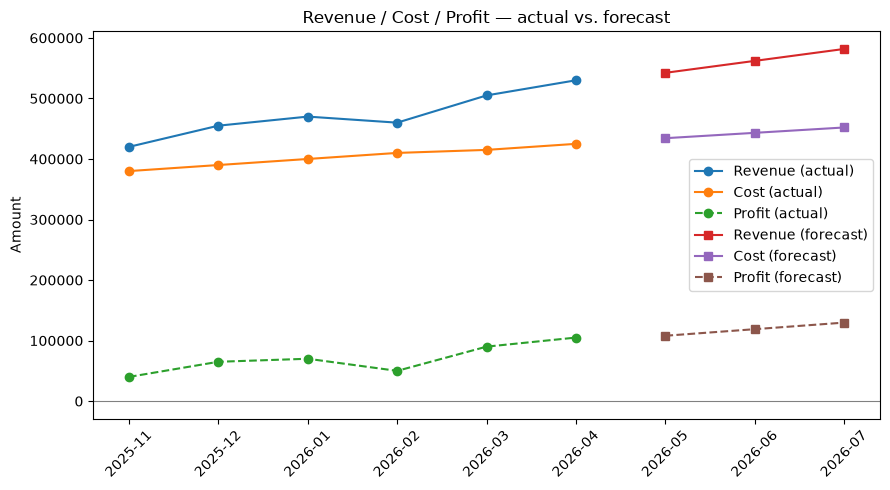


=== Final compiled report ===

Executive Report: Botanica Festive-Season Campaign & Financial Outlook

Botanica is launching a strategic festive-season campaign designed to position the brand as the premier choice for modern urban Indian women seeking clean, ritualistic skincare. Leveraging a brand identity that blends Ayurvedic botanicals with modern science, the campaign will roll out across Instagram, LinkedIn, and X, utilizing high-impact ad variants across Meta and Google alongside organic content pillars focused on festive glow, ingredient transparency, and conscious luxury. 

To expand our market presence beyond D2C, we have identified 6 key retail and distribution partners in India, short of the initial 8-partner target. To fully meet the objective, we must source 2 additional regional or boutique distributors. Our top identified onboarding targets include Nykaa, Amazon India, Sephora India, Tira, Myntra, and Shoppers Stop, which can be engaged directly through their respectiv

In [13]:
business_goal = (
    "Launch a festive-season sale campaign for our D2C skincare brand, "
    "find 8 potential retail/distribution partners in India, and tell me "
    "whether we're on track to be profitable next quarter."
)

financial_history = pd.DataFrame({
    "month": ["2025-11", "2025-12", "2026-01", "2026-02", "2026-03", "2026-04"],
    "revenue": [420000, 455000, 470000, 460000, 505000, 530000],
    "cost":    [380000, 390000, 400000, 410000, 415000, 425000],
})

demo_inputs = {
    "marketing_agent": dict(
        product="Botanica — natural skincare line",
        audience="Urban Indian women, 22-35, interested in clean beauty",
        platforms=["Instagram", "LinkedIn", "X"],
        goal="Drive festive-season sales and grow brand awareness",
    ),
    "lead_gen_agent": dict(
        icp_description="Boutique retail chains and e-commerce marketplaces open to stocking a new clean-beauty skincare brand",
        industry="beauty & personal care retail",
        region="India",
        max_results=8,
    ),
    "campaign_ops_agent": dict(
        brief="Diwali sale, 20% off, natural skincare brand, festive and premium feel",
        platforms=["Meta Ads", "Google Ads", "Instagram Organic"],
        audience="Urban Indian women, 22-35",
        total_budget=50000,
        num_days=7,
        comments=["Does this work for sensitive skin?", "When does the sale end?"],
    ),
    "revenue_predictor_agent": dict(history_df=financial_history, periods=3),
}

goal_result = orchestrator.execute(business_goal, demo_inputs)
print("\n=== Final compiled report ===\n")
print(goal_result["final_report"])


### Marketing strategy (detail)

*   List item
*   List item



In [14]:
print(json.dumps(goal_result["agent_outputs"]["marketing_agent"], indent=2))


{
  "positioning": "Botanica is a premium, home-grown natural skincare brand crafted specifically for the modern urban Indian woman navigating pollution, stress, and fast-paced lifestyles. By blending time-tested Ayurvedic botanicals with clean, modern science, Botanica delivers transparent, ritualistic self-care that nourishes the skin while honoring Indian heritage during festive celebrations and beyond.",
  "key_messages": [
    "Purity meets modern efficacy with 100% transparent, toxin-free natural ingredients tailored for urban Indian skin.",
    "Elevate your festive glow sustainably with ritual-inspired skincare that honors traditional roots.",
    "Conscious beauty that cares for your skin and the planet, offering zero-compromise luxury."
  ],
  "platform_plan": {
    "Instagram": {
      "content_pillars": [
        "Festive Skincare Rituals & Tutorials",
        "Ingredient Transparency & Behind-the-Scenes"
      ],
      "posting_cadence": "5x/week (3 Reels, 2 Carousels)",
 

### Qualified leads (detail)

In [15]:
display(goal_result["agent_outputs"]["lead_gen_agent"])

,organization,why_it_fits,likely_contact_channel,confidence,source_url
0,Nykaa,Major Indian e-commerce marketplace specializi...,company contact page / vendor onboarding portal,high,https://maearthbotanicals.com/blogs/botanical-...
1,Amazon India,Leading e-commerce marketplace utilized heavil...,company contact page / seller central,high,https://maearthbotanicals.com/blogs/botanical-...
2,Sephora India,Prominent beauty retail chain in India known f...,company contact page / retail partnership portal,medium,https://www.nexdigm.com/market-research/report...
3,Tira,Emerging beauty-focused retail platform and ma...,company contact page / vendor onboarding,medium,https://www.nexdigm.com/market-research/report...
4,Myntra,Major Indian e-commerce marketplace expanding ...,company contact page / vendor portal,medium,https://www.nexdigm.com/market-research/report...
5,Shoppers Stop,Established department store and boutique reta...,company contact page / retail buyer contact,medium,https://professionalbeauty.in/india-leads-glob...


### Campaign ops output (detail)

--- Ad copy variants ---


,platform,variant,headline,primary_text,description,cta
0,Meta Ads,1,Unlock Royal Diwali Glow | 20% Off,"This festive season, let your skin steal the s...",Limited time festive offer,Shop Now
1,Meta Ads,2,The Ultimate Festive Radiance Edit,Ditch the toxins. Embrace pure botanical luxur...,"Pure ingredients, radiant results",Explore Now
2,Meta Ads,3,Gift Pure Luxury | Flat 20% Off,Looking for the perfect Diwali gift? Pamper yo...,Celebrate with natural beauty,Get Offer
3,Google Ads,1,Natural Skincare Diwali Sale,Get Festive Ready With 20% Off,Discover pure botanical skincare for a luminou...,Shop Now
4,Google Ads,2,Luxury Herbal Glow Kits,Flat 20% Off Festive Skincare,Transform your skin this Diwali with 100% natu...,Buy Now
5,Google Ads,3,Diwali Skincare Gift Sets,Pure Glow & Festive Savings,"Gift the magic of pure, natural skincare. Enjo...",Shop Now
6,Instagram Organic,1,Light up your skin this Diwali ✨,"While the diyas light up your home, let our 10...",Festive glow unlocked,Shop Link in Bio
7,Instagram Organic,2,Your festive prep starts here 🌿,Clean beauty meets Diwali grandeur. 🪔 Skip the...,Pure ingredients for radiant skin,Shop Collection
8,Instagram Organic,3,The ultimate Diwali gifting guide 🎁,The secret to glowing skin this festive season...,Gift pure luxury,Explore Sets



--- Budget split ---


,platform,percent,rationale,budget_amount
0,Meta Ads,50.0,Visual carousel and video ads excel at showcas...,25000.0
1,Google Ads,35.0,Captures high-intent search traffic looking fo...,17500.0
2,Instagram Organic,15.0,"Builds brand aesthetics, festive community eng...",7500.0


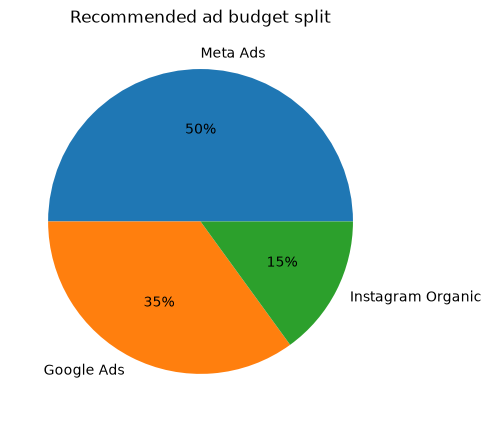


--- Content calendar ---


,date,platform,topic,caption,recommended_time
0,2026-08-24,Meta Ads,Diwali Glow Teaser & Early Access,Light up your skin this festive season! ✨ Get ...,09:00 AM
1,2026-08-25,Google Ads,Search Ad for Festive Skincare Bundles,Looking for the ultimate Diwali gift? Discover...,11:30 AM
2,2026-08-26,Instagram Organic,Reel: 3-Step Diwali Prep Routine,Get your festive glow on with our 3-step natur...,06:00 PM
3,2026-08-27,Meta Ads,Best-Sellers Retargeting Ad,Your festive favorites are waiting. 🌿 Pamper y...,02:00 PM
4,2026-08-28,Google Ads,Search Ad for Organic Face Serums,Achieve a flawless festive radiance. Buy pure ...,10:00 AM
5,2026-08-29,Instagram Organic,Carousel: Customer Testimonials & Festive Results,Hear from our glowing community! 💛 'My skin ha...,05:00 PM
6,2026-08-30,Meta Ads,Last Chance Diwali Sale Reminder,The celebrations are here! 🪔 Complete your fes...,08:00 PM



--- Creative contact sheet ---


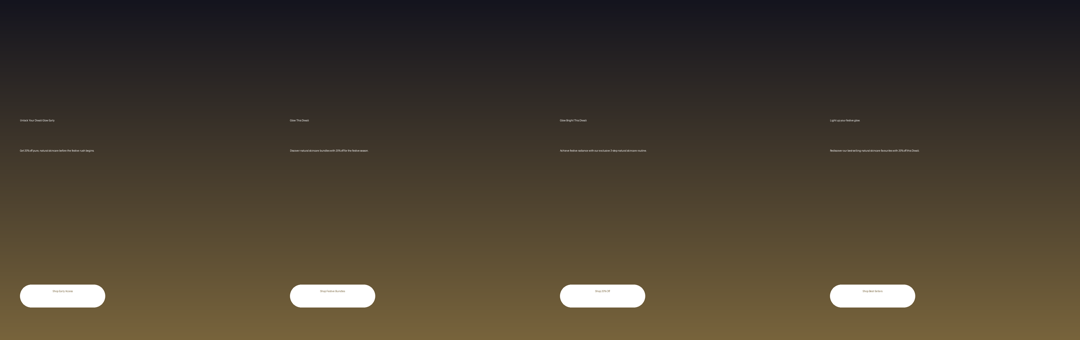


--- Engagement triage ---


,comment,sentiment,urgency,suggested_reply,needs_human_review
0,Does this work for sensitive skin?,neutral,low,"Great question! Yes, our formula is gentle and...",False
1,When does the sale end?,neutral,medium,Our sale wraps up this Sunday at midnight! Don...,False



Packaged for handoff: campaign_package_20260824_122746.zip


In [16]:
ops_result = goal_result["agent_outputs"]["campaign_ops_agent"]

print("--- Ad copy variants ---")
display(ops_result["ad_variants"])

if ops_result["budget_split"] is not None:
    print("\n--- Budget split ---")
    display(ops_result["budget_split"])
    campaign_ops_agent.plot_budget_split(ops_result["budget_split"])

print("\n--- Content calendar ---")
display(ops_result["content_calendar"])

print("\n--- Creative contact sheet ---")
display(Image.open(ops_result["contact_sheet_path"]))

if ops_result["engagement"] is not None:
    print("\n--- Engagement triage ---")
    display(ops_result["engagement"])

print(f"\nPackaged for handoff: {ops_result['package_path']}")
